<a href="https://colab.research.google.com/github/httperror505/Neural-Network/blob/colab/Rule_based_AI_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Using Rule-based per quiz only

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
# !pip install scikit-learn

In [ ]:
import pandas as pd

# Load dataset
data = pd.DataFrame([
    {"Question ID": "M1", "Question": "What is the primary function of the prostate gland?",
     "Options": "a. Store urine, b. Produce seminal fluid, c. Protect the kidneys, d. Regulate hormones",
     "Correct Answer": "b", "Topic": "Prostate Gland"},
    {"Question ID": "M2", "Question": "Which part of the male reproductive system is responsible for carrying urine and semen out?",
     "Options": "a. Bladder, b. Urethra, c. Penis, d. Prostate gland",
     "Correct Answer": "b", "Topic": "Urethra"},
    {"Question ID": "M3", "Question": "What is the role of the spermatic cord?",
     "Options": "a. To transport sperm and blood to the testes, b. To produce testosterone, c. To store urine, d. To filter blood",
     "Correct Answer": "a", "Topic": "Spermatic Cord"},
    {"Question ID": "M4", "Question": "What is the function of the testes?",
     "Options": "a. To produce and store sperm, b. To regulate blood flow, c. To store urine, d. To produce seminal fluid",
     "Correct Answer": "a", "Topic": "Testes"},
    {"Question ID": "M5", "Question": "Which organ is responsible for producing testosterone in males?",
     "Options": "a. Prostate gland, b. Testes, c. Kidney, d. Bladder",
     "Correct Answer": "b", "Topic": "Testes"},
    {"Question ID": "M6", "Question": "What is the primary function of the bladder?",
     "Options": "a. To produce sperm, b. To store urine, c. To produce seminal fluid, d. To transport sperm",
     "Correct Answer": "b", "Topic": "Bladder"},
    {"Question ID": "M7", "Question": "What is the function of the penis in the male reproductive system?",
     "Options": "a. To produce sperm, b. To deliver sperm into the female reproductive system, c. To regulate hormone production, d. To filter blood",
     "Correct Answer": "b", "Topic": "Penis"},
    {"Question ID": "M8", "Question": "What are the tiny tubes in the testes where sperm production occurs called?",
     "Options": "a. Urethra, b. Seminiferous tubules, c. Vas deferens, d. Epididymis",
     "Correct Answer": "b", "Topic": "Testes"},
    {"Question ID": "M9", "Question": "Where is sperm stored before ejaculation?",
     "Options": "a. Prostate gland, b. Vas deferens, c. Epididymis, d. Urethra",
     "Correct Answer": "c", "Topic": "Epididymis"},
    {"Question ID": "M10", "Question": "Which part of the male reproductive system transports sperm from the testes to the urethra?",
     "Options": "a. Vas deferens, b. Prostate gland, c. Seminiferous tubules, d. Bladder",
     "Correct Answer": "a", "Topic": "Vas Deferens"}
])

# Student answers example
student_answers = [
    {"Question ID": "M1", "Answer": "b"},
    {"Question ID": "M2", "Answer": "c"},
    {"Question ID": "M3", "Answer": "a"},
    {"Question ID": "M4", "Answer": "a"},
    {"Question ID": "M5", "Answer": "b"},
    {"Question ID": "M6", "Answer": "b"},
    {"Question ID": "M7", "Answer": "b"},
    {"Question ID": "M8", "Answer": "b"},
    {"Question ID": "M9", "Answer": "c"},
    {"Question ID": "M10", "Answer": "a"}
    # Add all answers here
]

# Merge student answers with dataset
answers_df = pd.DataFrame(student_answers)
results = pd.merge(data, answers_df, on="Question ID")
results['Is Correct'] = results['Answer'] == results['Correct Answer']

# Calculate performance per topic
performance = results.groupby('Topic')['Is Correct'].mean().reset_index()
performance.columns = ['Topic', 'Accuracy']

# Suggest topics for review
threshold = 0.7  # Set threshold for topic review
to_review = performance[performance['Accuracy'] < threshold]

# Display recommendations
print("Topics to Review:")
print(to_review)

# Measure the accuracy of the model
accuracy = results['Is Correct'].mean()
print(f"Model Accuracy: {accuracy * 100:.2f}%")



Topics to Review:
     Topic  Accuracy
6  Urethra       0.0
Model Accuracy: 90.00%


Model Accuracy: 90.00%


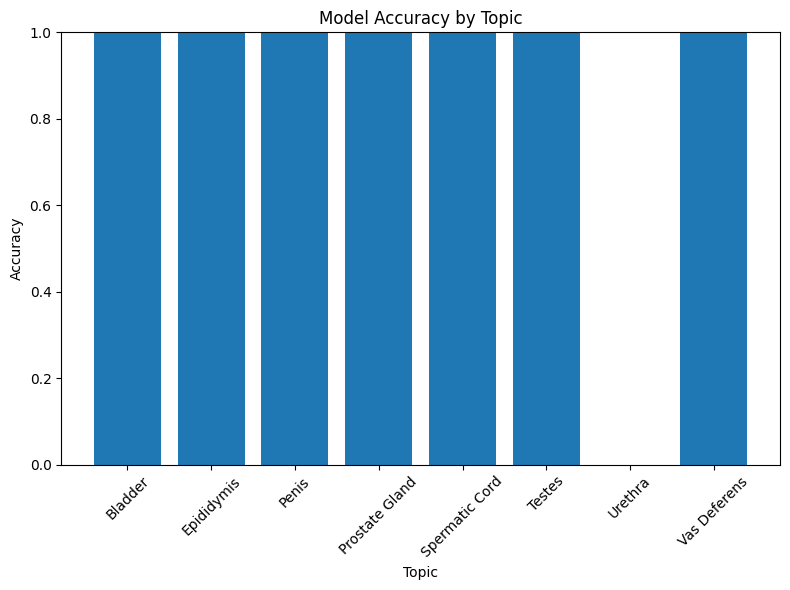

In [ ]:
import matplotlib.pyplot as plt

# Visualize the metrics of the model using matplotlib
# Measure the accuracy of the model
accuracy = results['Is Correct'].mean()
print(f"Model Accuracy: {accuracy * 100:.2f}%")

plt.figure(figsize=(8, 6))
plt.bar(performance['Topic'], performance['Accuracy'])

plt.xlabel('Topic')
plt.ylabel('Accuracy')
plt.title('Model Accuracy by Topic')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# show the graph
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Will be the filename of the trained model
filename = 'ai-male-thesis.pkl'

# Save the model
with open(filename, 'wb') as file:
    pickle.dump(results, file)

print(f"Model saved as {filename}")


Model saved as capstone_ai.pkl


In [ ]:
from google.colab import files

# Download the model file
files.download('ai-male-thesis.pkl')